# Laboratorio 01 - Machine Learning Operations

Integrantes:
- Melissa Pérez
- Renatto Guzmán
- Sebastían Silva
- Javier Alvarado

In [1]:
import pandas as pd

df = pd.read_csv("data/train.csv")
print(df.head())


   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False


## Análisis Exploratorio

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set(style="whitegrid")

DATA_DIR = Path("data")


In [3]:
# %%
train = pd.read_csv(DATA_DIR / "train.csv",
                    na_values=["NA", "NaN", ""],
                    parse_dates=["Date"])

test = pd.read_csv(DATA_DIR / "test.csv",
                   na_values=["NA", "NaN", ""],
                   parse_dates=["Date"])

stores = pd.read_csv(DATA_DIR / "stores.csv",
                     na_values=["NA", "NaN", ""])

features = pd.read_csv(DATA_DIR / "features.csv",
                       na_values=["NA", "NaN", ""],
                       parse_dates=["Date"])

df = train.copy()
print(df.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday
0      1     1 2010-02-05     24,924.50      False
1      1     1 2010-02-12     46,039.49       True
2      1     1 2010-02-19     41,595.55      False
3      1     1 2010-02-26     19,403.54      False
4      1     1 2010-03-05     21,827.90      False


In [4]:
# %%
def quick_info(df, name):
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    display(df.dtypes.to_frame("dtype").T)
    display(df.head())

quick_info(train, "train")
quick_info(test, "test")
quick_info(stores, "stores")
quick_info(features, "features")


=== train ===
Shape: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
dtype,int64,int64,datetime64[ns],float64,bool


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,"24,924.50",False
1,1,1,2010-02-12,"46,039.49",True
2,1,1,2010-02-19,"41,595.55",False
3,1,1,2010-02-26,"19,403.54",False
4,1,1,2010-03-05,"21,827.90",False


=== test ===
Shape: (115064, 4)


,Store,Dept,Date,IsHoliday
dtype,int64,int64,datetime64[ns],bool


...

,Store,Type,Size
dtype,int64,object,int64


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


=== features ===
Shape: (8190, 12)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
dtype,int64,datetime64[ns],float64,float64,float64,float64,float64,float64,float64,float64,float64,bool


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,2010-02-12,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,2010-02-19,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False
3,1,2010-02-26,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,False
4,1,2010-03-05,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,False


In [5]:
# %%
def date_range_info(df, date_col="Date", name="df"):
    print(f"{name}: {df[date_col].min().date()} → {df[date_col].max().date()} (n={df[date_col].nunique()} fechas)")

date_range_info(train, name="train")
date_range_info(test, name="test")
date_range_info(features, name="features")

print("\nStores únicas en train:", train["Store"].nunique())
print("Dept únicos en train:", train["Dept"].nunique())
print("Combinaciones Store-Dept en train:", train.groupby(["Store","Dept"]).size().shape[0])


train: 2010-02-05 → 2012-10-26 (n=143 fechas)
test: 2012-11-02 → 2013-07-26 (n=39 fechas)
features: 2010-02-05 → 2013-07-26 (n=182 fechas)

Stores únicas en train: 45
Dept únicos en train: 81
Combinaciones Store-Dept en train: 3331


In [6]:
# %%
def missing_summary(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if miss.empty:
        print(f"{name}: sin valores faltantes.")
        return
    pct = miss / len(df) * 100
    summary = pd.DataFrame({"missing": miss, "%": pct.round(2)})
    print(f"{name}:")
    display(summary)

missing_summary(train, "train")
missing_summary(features, "features")
missing_summary(stores, "stores")
missing_summary(test, "test")


train: sin valores faltantes.
features:


,missing,%
MarkDown2,5269,64.33
MarkDown4,4726,57.70
MarkDown3,4577,55.89
MarkDown1,4158,50.77
MarkDown5,4140,50.55
CPI,585,7.14
Unemployment,585,7.14


stores: sin valores faltantes.
test: sin valores faltantes.


In [7]:
# %%
def duplicate_check(df, name, subset=None):
    dups = df.duplicated(subset=subset)
    n = dups.sum()
    print(f"{name}: {n} duplicados", f"(subset={subset})" if subset else "")
    if n > 0:
        display(df[dups].head())

duplicate_check(train, "train", subset=["Store", "Dept", "Date"])
duplicate_check(features, "features", subset=["Store", "Date"])
duplicate_check(stores, "stores", subset=["Store"])
duplicate_check(test, "test", subset=["Store", "Dept", "Date"])


train: 0 duplicados (subset=['Store', 'Dept', 'Date'])
features: 0 duplicados (subset=['Store', 'Date'])
stores: 0 duplicados (subset=['Store'])
test: 0 duplicados (subset=['Store', 'Dept', 'Date'])


In [8]:
# %%
train_full = (
    train.merge(stores, on="Store", how="left")
         .merge(features, on=["Store", "Date"], how="left")
)

print("train_full shape:", train_full.shape)
display(train_full.head())


train_full shape: (421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,"24,924.50",False,A,151315,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,1,2010-02-12,"46,039.49",True,A,151315,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,1,2010-02-19,"41,595.55",False,A,151315,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False
3,1,1,2010-02-26,"19,403.54",False,A,151315,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,False
4,1,1,2010-03-05,"21,827.90",False,A,151315,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,False


,count,mean,std,min,25%,50%,75%,max
Store,"421,570.00",22.20,12.79,1.00,11.00,22.00,33.00,45.00
Dept,"421,570.00",44.26,30.49,1.00,18.00,37.00,74.00,99.00
Weekly_Sales,"421,570.00","15,981.26","22,711.18","-4,988.94","2,079.65","7,612.03","20,205.85","693,099.36"
Size,"421,570.00","136,727.92","60,980.58","34,875.00","93,638.00","140,167.00","202,505.00","219,622.00"
Temperature,"421,570.00",60.09,18.45,-2.06,46.68,62.09,74.28,100.14
Fuel_Price,"421,570.00",3.36,0.46,2.47,2.93,3.45,3.74,4.47
MarkDown1,"150,681.00","7,246.42","8,291.22",0.27,"2,240.27","5,347.45","9,210.90","88,646.76"
MarkDown2,"111,248.00","3,334.63","9,475.36",-265.76,41.60,192.00,"1,926.94","104,519.54"
MarkDown3,"137,091.00","1,439.42","9,623.08",-29.10,5.08,24.60,103.99,"141,630.61"
MarkDown4,"134,967.00","3,383.17","6,292.38",0.22,504.22,"1,481.31","3,595.04","67,474.85"


,count,mean,min,25%,50%,75%,max
Date,421570,2011-06-18 08:30:31.963375104,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00


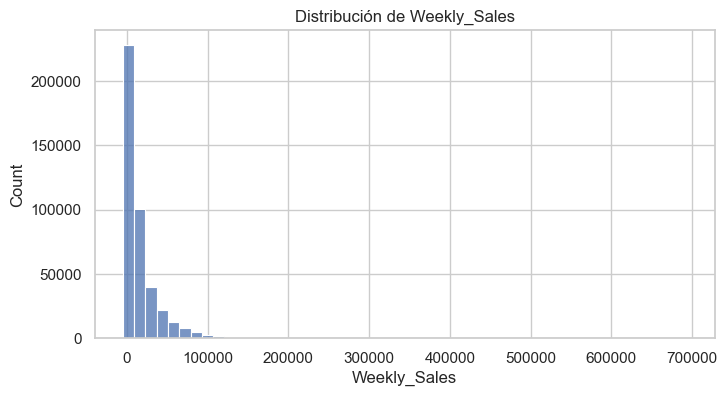

In [9]:
# %%
desc_numeric = train_full.select_dtypes(include=[np.number]).describe().T
display(desc_numeric)

desc_cat = train_full.select_dtypes(exclude=[np.number]).describe().T
display(desc_cat)

# %%
plt.figure(figsize=(8,4))
sns.histplot(train["Weekly_Sales"], bins=50)
plt.title("Distribución de Weekly_Sales")
plt.xlabel("Weekly_Sales")
plt.show()



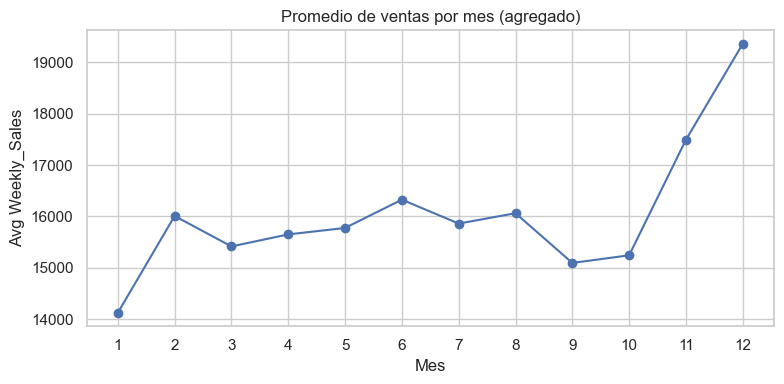

In [10]:
# %%
train_fe = train.copy()
train_fe["Year"] = train_fe["Date"].dt.year
train_fe["Month"] = train_fe["Date"].dt.month
train_fe["Week"] = train_fe["Date"].dt.isocalendar().week.astype(int)

monthly_avg = train_fe.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(8,4))
monthly_avg.plot(marker="o")
plt.title("Promedio de ventas por mes (agregado)")
plt.xlabel("Mes")
plt.ylabel("Avg Weekly_Sales")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()


In [11]:
# %%
# Copia del DataFrame final a un archivo CSV
train_full.to_csv(DATA_DIR / "train_full_raw.csv", index=False)
print("Archivo guardado: train_full_raw.csv")


Archivo guardado: train_full_raw.csv


## Feature Engineering para el Modelo

Preparamos las variables necesarias para entrenar el modelo de machine learning.

In [12]:
# Feature Engineering
print("Columnas disponibles en train_full:")
print(train_full.columns.tolist())
print(f"\nShape de train_full: {train_full.shape}")

Columnas disponibles en train_full:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y']

Shape de train_full: (421570, 17)


In [13]:
# Agregar variables de tiempo
train_full["Year"] = train_full["Date"].dt.year
train_full["Month"] = train_full["Date"].dt.month
train_full["Week"] = train_full["Date"].dt.isocalendar().week.astype(int)

In [14]:
# Imputar valores faltantes en MarkDowns (si existen)
markdown_cols = [col for col in train_full.columns if 'MarkDown' in col]
if markdown_cols:
    train_full[markdown_cols] = train_full[markdown_cols].fillna(0)
    print(f"MarkDown columns imputadas: {markdown_cols}")

# Convertir IsHoliday a numérico si existe
if 'IsHoliday' in train_full.columns:
    train_full["IsHoliday"] = train_full["IsHoliday"].astype(int)
    print("IsHoliday convertido a numérico")

# Crear Sales Lag (variable importante para predicción)
train_full = train_full.sort_values(["Store", "Dept", "Date"])
train_full["Sales_Lag_1"] = train_full.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)

print(f"\nFeature engineering completado.")
print(f"Shape final: {train_full.shape}")
print(f"Nuevas columnas: Year, Month, Week, Sales_Lag_1")

# Mostrar resumen de valores faltantes
print(f"\nValores faltantes:")
missing_counts = train_full.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
for col, count in missing_counts.items():
    print(f"  {col}: {count} ({count/len(train_full)*100:.1f}%)")

MarkDown columns imputadas: ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

Feature engineering completado.
Shape final: (421570, 21)
Nuevas columnas: Year, Month, Week, Sales_Lag_1

Valores faltantes:
  Sales_Lag_1: 3331 (0.8%)
